# Market Sentiment Classification
This notebook contains the experimental version of the project. It will cover:

1. Data loading and checking
2. Data exploration
3. Train/validation split
4. Data preprocessing
5. Feature engineering: BoW, TF-IDF, Word2Vec, Transformer Encoder
6. Classification models and evaluation
7. Final test prediction file generation
   
Labels: **0 = Bearish**, **1 = Bullish**, **2 = Neutral**.

# 1. Data Import

In [132]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import random

from wordcloud import WordCloud
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from nltk.stem import WordNetLemmatizer
from collections import Counter
from sklearn.model_selection import train_test_split

pd.set_option("display.max_colwidth", None)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

In [5]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

In [6]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
train_df.head()

Train shape: (9543, 2)
Test shape: (2388, 2)


,text,label
0,$BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT,0
1,$CCL $RCL - Nomura points to bookings weakness at Carnival and Royal Caribbean https://t.co/yGjpT2ReD3,0
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan on weak building outlook https://t.co/KN1g4AWFIb",0
3,$ESS: BTIG Research cuts to Neutral https://t.co/MCyfTsXc2N,0
4,$FNKO - Funko slides after Piper Jaffray PT cut https://t.co/z37IJmCQzB,0


In [7]:
print("Train columns:", train_df.columns.tolist())
print("Test columns:", test_df.columns.tolist())

Train columns: ['text', 'label']
Test columns: ['id', 'text']


# 2. EDA

In [9]:
train_df.info()
test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9543 entries, 0 to 9542
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    9543 non-null   str  
 1   label   9543 non-null   int64
dtypes: int64(1), str(1)
memory usage: 954.7 KB
<class 'pandas.DataFrame'>
RangeIndex: 2388 entries, 0 to 2387
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      2388 non-null   int64
 1   text    2388 non-null   str  
dtypes: int64(1), str(1)
memory usage: 241.4 KB


In [10]:
print("Missing values in train:")
print(train_df.isnull().sum())
print()

print("Missing values in test:")
print(test_df.isnull().sum())

Missing values in train:
text     0
label    0
dtype: int64

Missing values in test:
id      0
text    0
dtype: int64


In [11]:
print("Duplicate rows in train:", train_df.duplicated().sum())
print("Duplicate rows in test:", test_df.duplicated().sum())

Duplicate rows in train: 0
Duplicate rows in test: 0


In [12]:
print("Duplicate texts in train:", train_df['text'].duplicated().sum())
print("Duplicate texts in test:", test_df['text'].duplicated().sum())

Duplicate texts in train: 0
Duplicate texts in test: 0


In [13]:
train_df['label'].value_counts().sort_index()

label
0    1442
1    1923
2    6178
Name: count, dtype: int64

In [14]:
train_df[10:20]

,text,label
10,$HOG - Moody's warns on Harley-Davidson https://t.co/LurHBEadeU,0
11,"$HXL - Citing aero ties, Wells slashes PT on Hexcel https://t.co/wU5P2i8WBU",0
12,$I - Intelsat cut to Market Perform at Raymond James https://t.co/YsvsMSQRIb,0
13,$KRG: Compass Point cuts to Sell https://t.co/MCyfTsXc2N,0
14,$LK - Muddy Waters goes short Luckin Coffee https://t.co/8yrbwAjLKG,0
15,$MANT - ManTech downgraded ahead of difficult comps https://t.co/mJ1eSrsFXJ,0
16,$MDCO: Oppenheimer cuts to Perform,0
17,$MPLX $MPC - MPLX cut at Credit Suisse on potential dilution from Marathon strategic review https://t.co/0BFQy4ZU6W,0
18,$MSGN - Imperial downgrades MSG Networks amid sports-free airwaves https://t.co/Ul2S6XNXw8,0
19,$MTLS - Piper hits the Materialise sidelines https://t.co/qlFxZuhkrt,0


In [15]:
label_map = {0:"Bearish", 1:"Bullish", 2:"Neutral"}
train_df['LabelName'] = train_df["label"].map(label_map)
label_table = pd.DataFrame({
    'count': train_df['LabelName'].value_counts(),
    'percentage': (train_df['LabelName'].value_counts(normalize=True) * 100).round(2),
})
display(label_table)

,count,percentage
LabelName,,
Neutral,6178,64.74
Bullish,1923,20.15
Bearish,1442,15.11


## Dependent feature

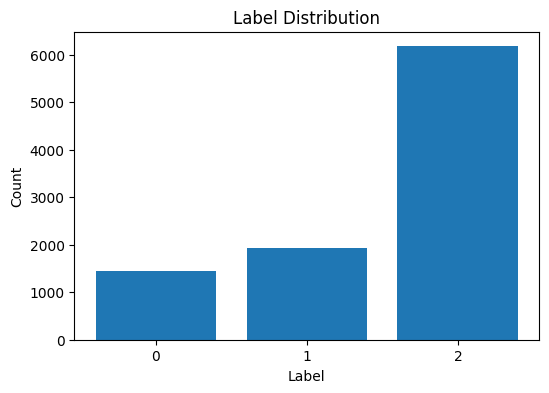

In [17]:
label_counts = train_df['label'].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(label_counts.index.astype(str), label_counts.values)
plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

In [18]:
train_df["TextLength"] = train_df['text'].astype(str).str.len()
train_df["WordCount"] = train_df['text'].astype(str).apply(lambda x:len(x.split()))
display(train_df[["TextLength","WordCount"]].describe())

display(train_df.groupby('LabelName')[["TextLength","WordCount"]].mean().round(2))

,TextLength,WordCount
count,9543.000000,9543.000000
mean,85.816934,12.178351
std,35.097229,4.665599
min,2.000000,1.000000
25%,58.000000,9.000000
50%,79.000000,11.000000
75%,120.000000,15.000000
max,190.000000,32.000000


,TextLength,WordCount
LabelName,,
Bearish,83.32,12.00
Bullish,80.38,11.93
Neutral,88.09,12.30


In [19]:
train_df

,text,label,LabelName,TextLength,WordCount
0,$BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT,0,Bearish,77,10
1,$CCL $RCL - Nomura points to bookings weakness at Carnival and Royal Caribbean https://t.co/yGjpT2ReD3,0,Bearish,102,14
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan on weak building outlook https://t.co/KN1g4AWFIb",0,Bearish,94,14
3,$ESS: BTIG Research cuts to Neutral https://t.co/MCyfTsXc2N,0,Bearish,59,7
4,$FNKO - Funko slides after Piper Jaffray PT cut https://t.co/z37IJmCQzB,0,Bearish,71,10
...,...,...,...,...,...
9538,The Week's Gainers and Losers on the Stoxx Europe 50 --Dec. 2-6 #economy #MarketScreener https://t.co/iK5MO4NhQq https://t.co/AJh5V5fWTT,2,Neutral,136,16
9539,Tupperware Brands among consumer gainers; Unilever leads the losers,2,Neutral,67,9
9540,vTv Therapeutics leads healthcare gainers; Myomo and Biohaven Pharmaceutical among losers,2,Neutral,89,11
9541,"WORK, XPO, PYX and AMKR among after hour movers",2,Neutral,47,9


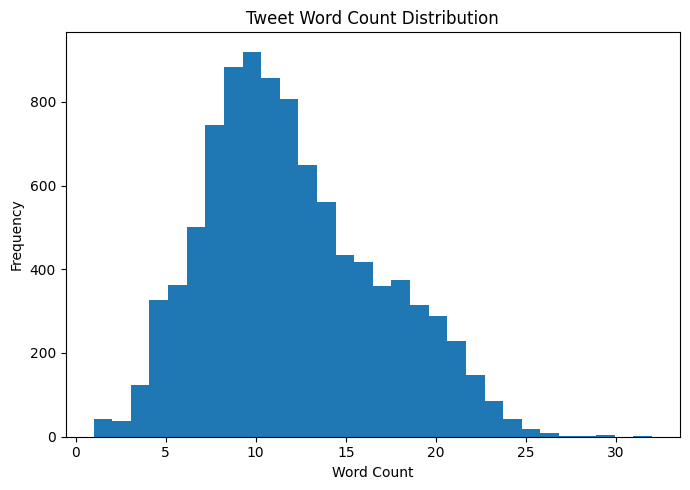

In [20]:
plt.figure(figsize=(7, 5))
train_df["WordCount"].plot(kind="hist", bins=30)
plt.title("Tweet Word Count Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [21]:

important_words = {
    "up", "down", "buy", "sell", "bull", "bear", "bullish", "bearish",
    "profit", "loss", "long", "short", "gain", "gains", "drop", "drops",
    "rally", "rallies", "rise", "rises", "fall", "falls", "low", "high",
    "beat", "miss", "upgrade", "downgrade"
}

stop_words = set(ENGLISH_STOP_WORDS) - important_words

In [22]:
def clean_text(text):
    """Clean a tweet using regular expressions."""
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)       # remove URLs
    text = re.sub(r"@\w+", " ", text)                            # remove mentions
    text = re.sub(r"#", "", text)                                 # keep hashtag words
    text = re.sub(r"\$([a-zA-Z]+)", r" \1 ", text)               # $AAPL -> AAPL
    text = re.sub(r"[^a-zA-Z\s]", " ", text)                     # remove symbols/numbers
    text = re.sub(r"\s+", " ", text).strip()                     # remove extra spaces
    return text
    

## Stemming and Lemmatization

In [24]:
lemma = WordNetLemmatizer()
def stem_simple(word):
    """A small fallback stemmer so the notebook runs without extra downloads."""
    for suffix in ['ing','edly','ed','ly','ies','s']:
        if word.endswith(suffix) and len(word) > len(suffix)+3:
            if suffix == "ies":
                return word[:-3] + "y"
            return word[:-len(suffix)]
    return word

def preprocess_lemma(text):
    """Basic cleaning + stopword removal. Used as the main normalized text column."""
    cleaned = clean_text(text)
    tokens = [lemma.lemmatize(w) for w in cleaned.split() if w not in stop_words and len(w)>2]
    return " ".join(tokens)

def preprocess_stem(text):
    cleaned = clean_text(text)
    tokens = [stem_simple(w) for w in cleaned.split() if w not in stop_words and len(w)>2]
    return " ".join(tokens)
    

In [25]:
for df in [train_df, test_df]:
    df['CleanBasic'] = df['text'].apply(clean_text)
    df['CleanLemmatize'] = df['text'].apply(preprocess_lemma)
    df['CleanStmmer'] = df['text'].apply(preprocess_stem)
    df['TextLength'] = df['text'].astype(str).str.len()
    df['TextCount'] = df['text'].astype(str).apply(lambda x: len(str(x).split()))
display(train_df[['text','CleanBasic','CleanLemmatize','CleanStmmer']].head())

,text,CleanBasic,CleanLemmatize,CleanStmmer
0,$BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT,bynd jpmorgan reels in expectations on beyond meat,bynd jpmorgan reel expectation meat,bynd jpmorgan reel expectation meat
1,$CCL $RCL - Nomura points to bookings weakness at Carnival and Royal Caribbean https://t.co/yGjpT2ReD3,ccl rcl nomura points to bookings weakness at carnival and royal caribbean,ccl rcl nomura point booking weakness carnival royal caribbean,ccl rcl nomura point booking weaknes carnival royal caribbean
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan on weak building outlook https://t.co/KN1g4AWFIb",cx cemex cut at credit suisse j p morgan on weak building outlook,cemex cut credit suisse morgan weak building outlook,cemex cut credit suisse morgan weak build outlook
3,$ESS: BTIG Research cuts to Neutral https://t.co/MCyfTsXc2N,ess btig research cuts to neutral,es btig research cut neutral,ess btig research cuts neutral
4,$FNKO - Funko slides after Piper Jaffray PT cut https://t.co/z37IJmCQzB,fnko funko slides after piper jaffray pt cut,fnko funko slide piper jaffray cut,fnko funko slide piper jaffray cut


* Lemmatization is used for the final modeling text because it produces cleaner, more meaningful normalized tweets.

,word,frequency
0,stock,1341
1,market,571
2,marketscreener,480
3,new,417
4,report,403
5,price,394
6,say,393
7,result,382
8,earnings,352
9,share,343


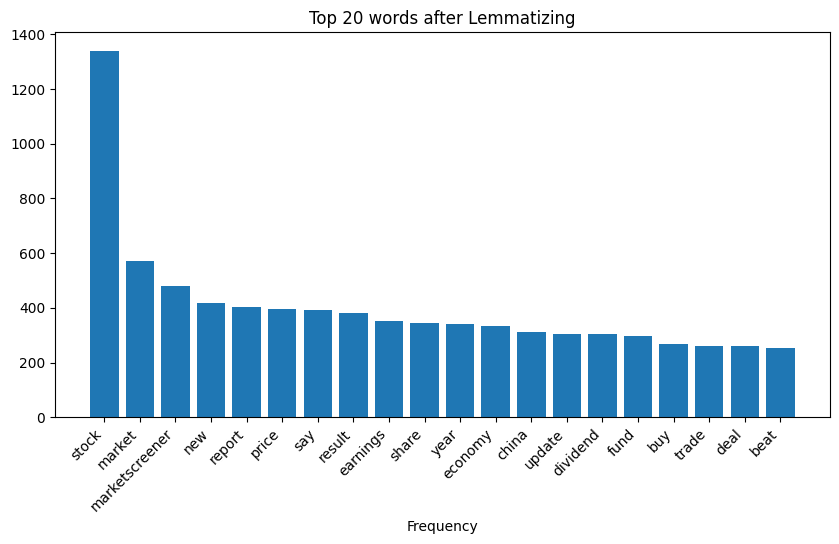

In [122]:
from collections import Counter
all_words = " ".join(train_df['CleanLemmatize'].fillna("")).split()
top_words = pd.DataFrame(Counter(all_words).most_common(20), columns=['word','frequency'])
display(top_words)
plt.figure(figsize=(10,5))
plt.bar(top_words['word'],top_words['frequency'])
plt.title("Top 20 words after Lemmatizing")
plt.xlabel("Word")
plt.xlabel("Frequency")
plt.xticks(rotation=45,ha='right')
plt.show()

In [140]:
X_train, X_val, y_train, y_val = train_test_split(
    train_df['CleanLemmatize'],
    train_df['label'],
    test_size = 0.20,
    random_state = RANDOM_STATE,
    stratify = train_df['label']
)